# Heston Model Review: Intuition, Parameters, and Extreme Examples

The Heston model is a stochastic-volatility model: the stock price changes randomly, and its **variance** also changes randomly over time. This notebook introduces the model, interprets its parameters, and visualizes what happens when $\kappa$, $\theta$, and $\rho$ are very low or very high.

## 1. The model

The Heston model has two coupled stochastic processes:

$$
dS_t = \mu S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{(S)},
$$

$$
dv_t = \kappa(\theta-v_t)\,dt + \sigma_v\sqrt{v_t}\,dW_t^{(v)},
$$

with

$$
dW_t^{(S)} dW_t^{(v)} = \rho\,dt.
$$

The stock price is $S_t$. The hidden state $v_t$ is the **instantaneous variance**. Its square root, $\sqrt{v_t}$, is instantaneous volatility.

## 2. Heston parameters

| Parameter | Meaning |
|---|---|
| $S_0$ | Initial stock price |
| $v_0$ | Initial latent variance |
| $\kappa$ | Mean-reversion speed of variance |
| $\theta$ | Long-run target variance |
| $\sigma_v$ | Volatility of variance, or *vol-of-vol* |
| $\rho$ | Correlation between price and variance shocks |
| $\mu$ | Expected return under the real-world measure |

The main machine-learning targets in this project are

```text
[v0, kappa, theta, sigma_v, rho]
```

## 3. Latent variance and log returns

Variance is called **latent** because in real markets we observe prices or returns, not the exact hidden $v_t$ that generated them.

The daily log return is

$$
r_t = \log\left(\frac{S_t}{S_{t-1}}\right).
$$

For a neural-network experiment, the natural setup is:

```text
Input:   a sequence of simulated daily log returns
Target:  [v0, kappa, theta, sigma_v, rho]
```

The latent variance path is useful for inspecting the simulator, but should not be used as input if you want to mimic inference from observed prices alone.

## 4. Parameter intuition before plotting

### $\kappa$: mean-reversion speed

$\kappa$ controls how quickly variance is pulled back toward $\theta$.

- Very low $\kappa$: volatility regimes persist for a long time.
- Very high $\kappa$: variance snaps back toward $\theta$ quickly after shocks.

Ignoring random shocks, deviations decay approximately as $e^{-\kappa t}$, so a rough timescale is $1/\kappa$ years.

### $\theta$: long-run variance target

$\theta$ is the center that variance tends to return toward. It is variance, not volatility. For example:

$$
\theta = 0.04 \quad \Longrightarrow \quad \sqrt{\theta}=20\%\text{ annualized volatility}.
$$

### $\rho$: price/variance-shock correlation

$\rho$ determines whether price shocks and variance shocks tend to move together.

- Negative $\rho$: a negative price shock tends to coincide with a positive variance shock. This is typical for equity markets.
- Positive $\rho$: positive price shocks tend to coincide with increasing variance.
- Near-zero $\rho$: the two shocks are nearly independent.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_heston_one_path(
    S0=100.0,
    v0=0.04,
    kappa=2.0,
    theta=0.04,
    sigma_v=0.6,
    rho=-0.7,
    mu=0.0,
    years=2,
    trading_days_per_year=252,
    seed=123
):
    #\"\"\"Simulate one Heston path using full-truncation Euler.\"\"\"

    rng = np.random.default_rng(seed)
    n_steps = years * trading_days_per_year
    dt = 1.0 / trading_days_per_year
    sqrt_dt = np.sqrt(dt)

    log_returns = np.zeros(n_steps)
    variance = np.zeros(n_steps + 1)
    variance[0] = v0

    for t in range(n_steps):
        z_variance = rng.standard_normal()
        z_independent = rng.standard_normal()

        z_price = (
            rho * z_variance
            + np.sqrt(1.0 - rho**2) * z_independent
        )

        v_positive = max(variance[t], 0.0)

        log_returns[t] = (
            (mu - 0.5 * v_positive) * dt
            + np.sqrt(v_positive) * sqrt_dt * z_price
        )

        variance[t + 1] = max(
            variance[t]
            + kappa * (theta - v_positive) * dt
            + sigma_v * np.sqrt(v_positive) * sqrt_dt * z_variance,
            0.0
        )

    prices = S0 * np.exp(np.concatenate([[0.0], np.cumsum(log_returns)]))

    return prices, log_returns, variance


def plot_price_and_variance(result, title, theta=None):
    #\"\"\"Plot a price path and its hidden variance path.\"\"\"

    prices, log_returns, variance = result
    days = np.arange(len(prices))

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    axes[0].plot(days, prices)
    axes[0].set_ylabel('Price')
    axes[0].set_title(title)
    axes[0].grid(alpha=0.3)

    axes[1].plot(days, variance, label='latent variance $v_t$')
    if theta is not None:
        axes[1].axhline(
            theta,
            linestyle='--',
            label=f'long-run variance theta = {theta:.3f}'
        )
    axes[1].set_xlabel('Trading day')
    axes[1].set_ylabel('Variance')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 5. Very low versus very high $\kappa$

We hold all other parameters fixed. The two paths below use the same random seed, so their shocks are comparable. The main difference is how strongly variance is pulled back to $\theta=0.04$.

- **Low $\kappa=0.25$**: a rough mean-reversion timescale of about four years. High or low variance can persist.
- **High $\kappa=8.0$**: a rough mean-reversion timescale of about 1.5 months. Variance is pulled back rapidly.

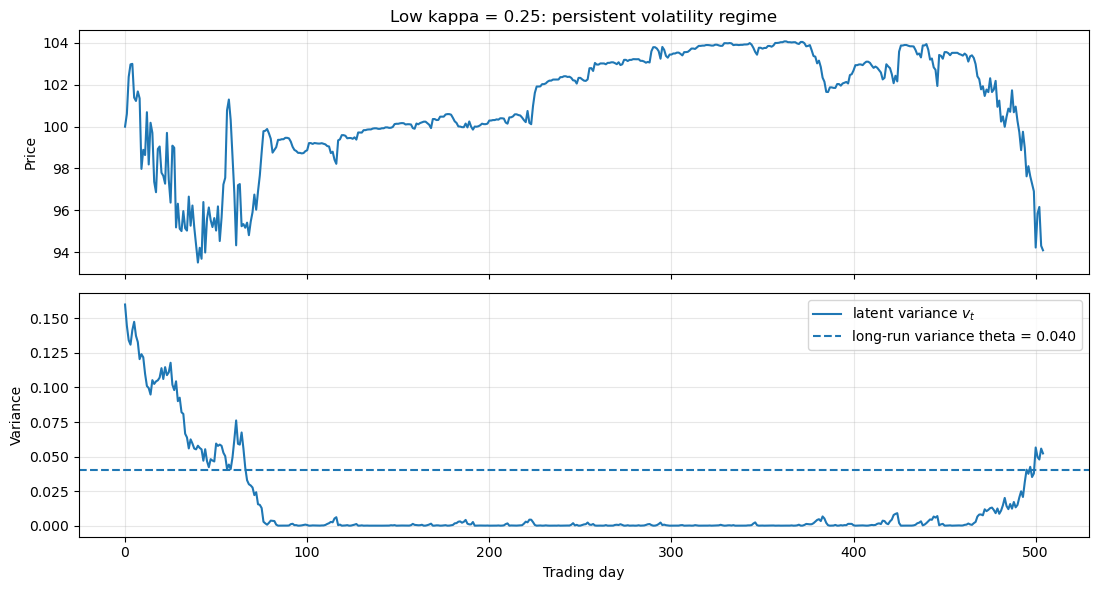

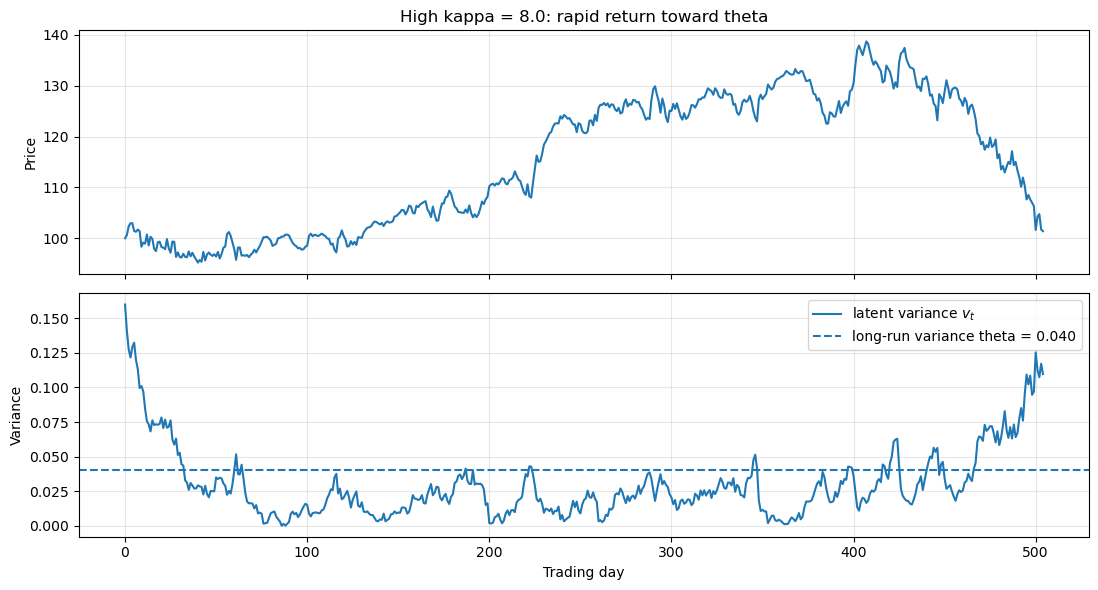

In [3]:
common = dict(
    S0=100.0,
    v0=0.16,
    theta=0.04,
    sigma_v=0.55,
    rho=-0.7,
    years=2,
    seed=10
)

low_kappa = simulate_heston_one_path(kappa=0.25, **common)
high_kappa = simulate_heston_one_path(kappa=8.0, **common)

plot_price_and_variance(
    low_kappa,
    title='Low kappa = 0.25: persistent volatility regime',
    theta=0.04
)

plot_price_and_variance(
    high_kappa,
    title='High kappa = 8.0: rapid return toward theta',
    theta=0.04
)


### What to look for

With low $\kappa$, the initial high variance $v_0=0.16$ can remain elevated for much longer. With high $\kappa$, the deterministic pull toward $\theta=0.04$ is much stronger, although random vol-of-vol shocks still move variance around.

## 6. Very low versus very high $\theta$

Now we hold $\kappa$ fixed and change the long-run target variance.

- **Low $\theta=0.01$** corresponds to a long-run volatility target of $10\%$.
- **High $\theta=0.16$** corresponds to a long-run volatility target of $40\%$.

This is not merely a short-term effect: it changes the typical volatility regime toward which the model is drawn.

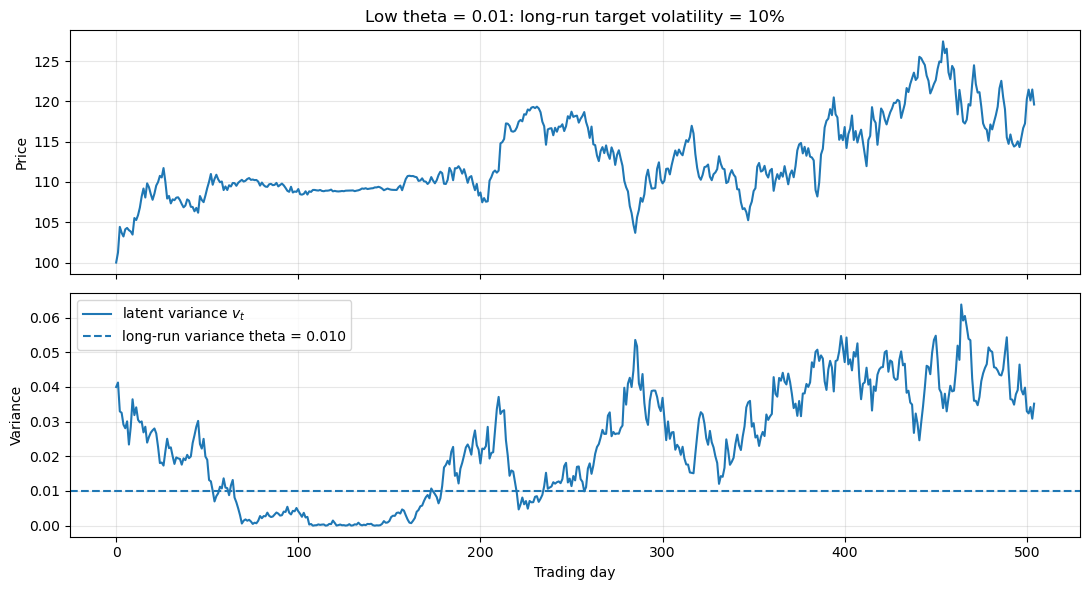

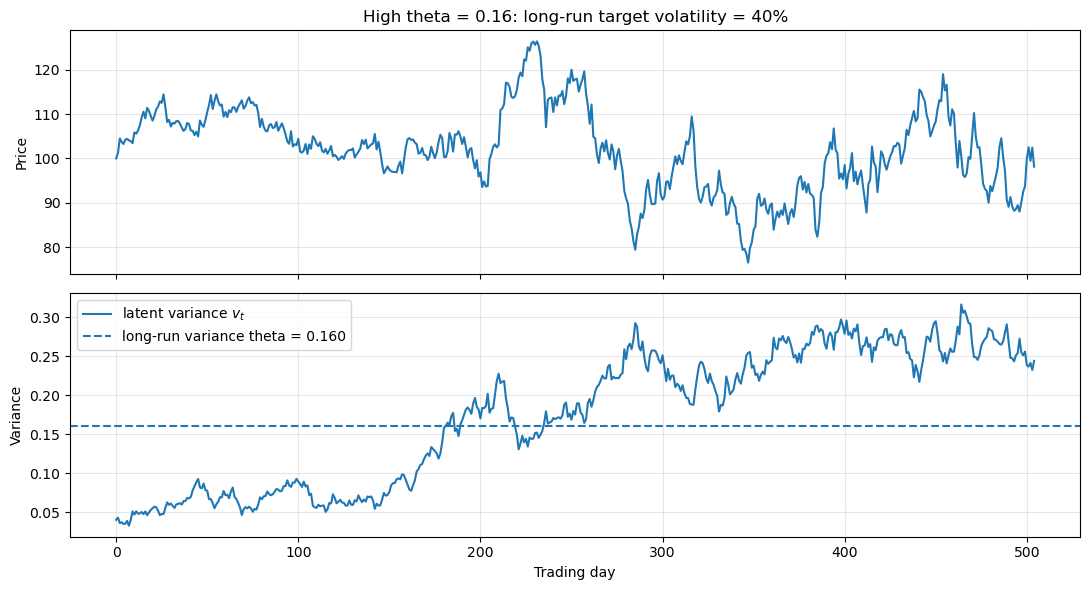

In [4]:
common = dict(
    S0=100.0,
    v0=0.04,
    kappa=2.5,
    sigma_v=0.35,
    rho=-0.6,
    years=2,
    seed=21
)

low_theta = simulate_heston_one_path(theta=0.01, **common)
high_theta = simulate_heston_one_path(theta=0.16, **common)

plot_price_and_variance(
    low_theta,
    title='Low theta = 0.01: long-run target volatility = 10%',
    theta=0.01
)

plot_price_and_variance(
    high_theta,
    title='High theta = 0.16: long-run target volatility = 40%',
    theta=0.16
)


### What to look for

The high-$\theta$ path tends to spend more time at higher variance and therefore has larger typical daily price moves. The low-$\theta$ path is continually pulled toward a calmer volatility level.

## 7. Very negative, zero, and very positive $\rho$

$\rho$ is the correlation between the price shock and the variance shock on the same time step. We will use the same variance shocks and same independent shocks in each simulation by keeping the random seed fixed.

- **Very negative $\rho=-0.95$**: down moves tend to happen with variance increases.
- **Near zero $\rho=0$**: price and variance shocks are nearly unrelated.
- **Very positive $\rho=+0.95$**: up moves tend to happen with variance increases.

For equity-index-style behavior, negative $\rho$ is usually the relevant regime.

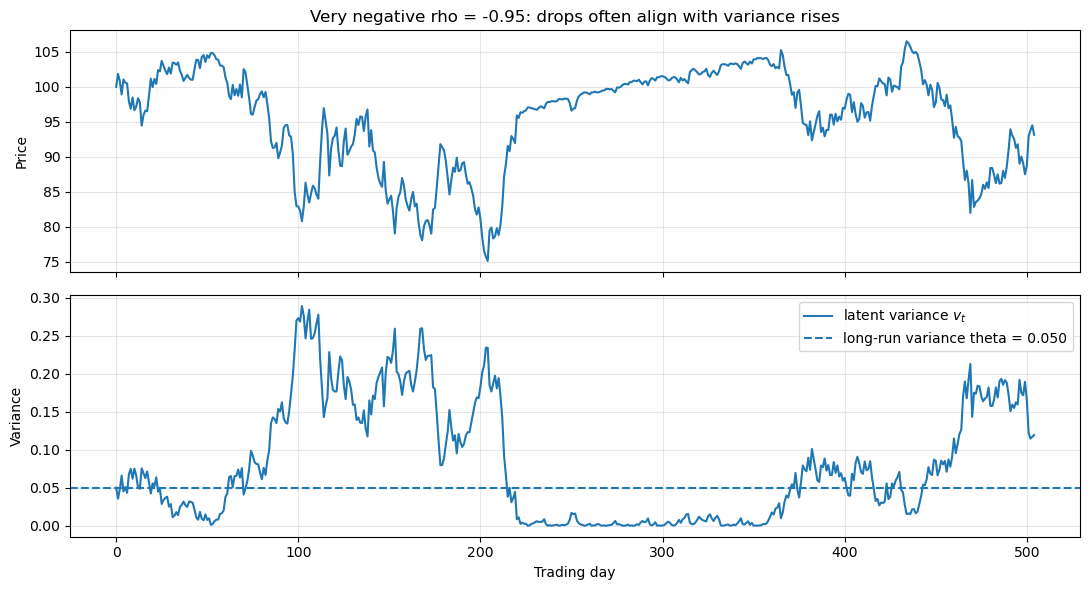

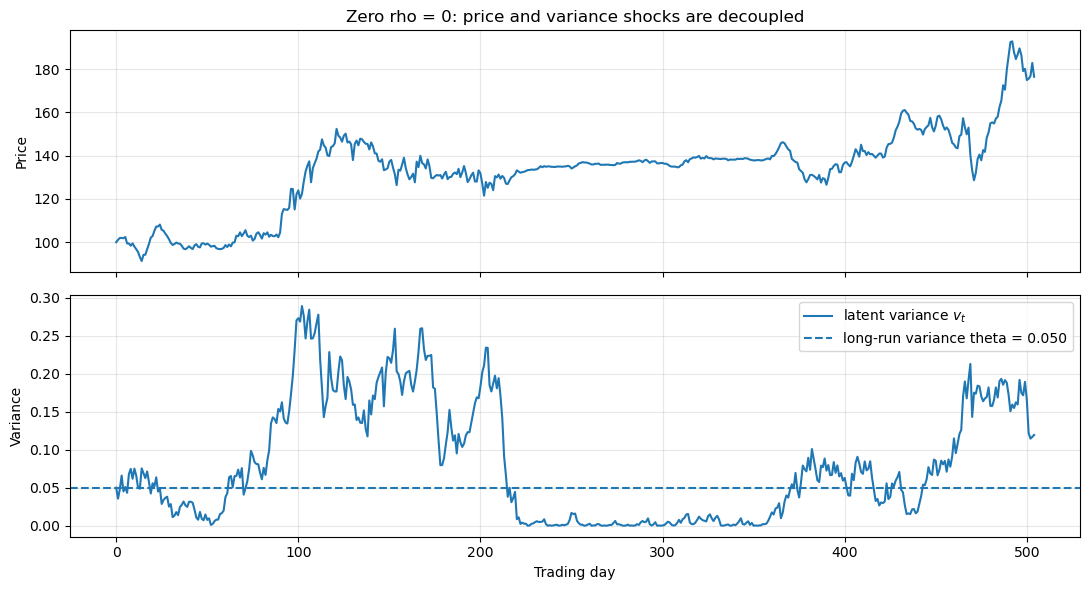

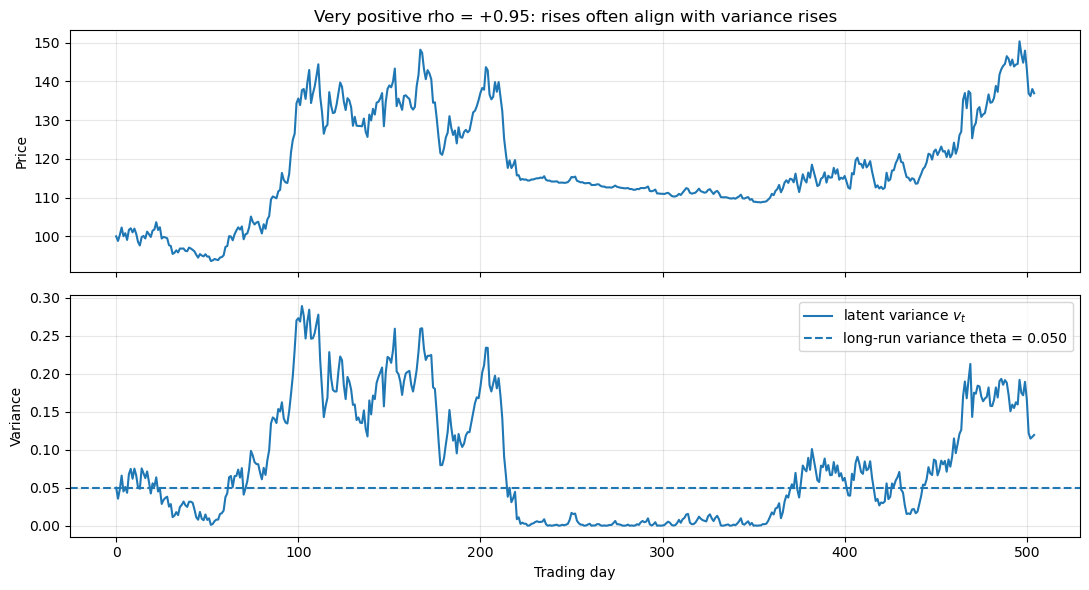

In [5]:
common = dict(
    S0=100.0,
    v0=0.05,
    kappa=2.0,
    theta=0.05,
    sigma_v=0.9,
    years=2,
    seed=35
)

negative_rho = simulate_heston_one_path(rho=-0.95, **common)
zero_rho = simulate_heston_one_path(rho=0.0, **common)
positive_rho = simulate_heston_one_path(rho=0.95, **common)

plot_price_and_variance(
    negative_rho,
    title='Very negative rho = -0.95: drops often align with variance rises',
    theta=0.05
)

plot_price_and_variance(
    zero_rho,
    title='Zero rho = 0: price and variance shocks are decoupled',
    theta=0.05
)

plot_price_and_variance(
    positive_rho,
    title='Very positive rho = +0.95: rises often align with variance rises',
    theta=0.05
)


## 8. A direct numerical check of the leverage effect

The following cell estimates the correlation between each day's return and the next day's variance change. This is not exactly $\rho$, because the model has dynamics and discretization, but it provides a helpful diagnostic.

For the negative-$\rho$ case, the relationship should usually be negative: down returns tend to be associated with later or simultaneous variance increases.

In [6]:
def return_variance_change_correlation(result):
    prices, log_returns, variance = result
    variance_changes = np.diff(variance)
    return np.corrcoef(log_returns, variance_changes)[0, 1]


for label, result in [
    ('rho = -0.95', negative_rho),
    ('rho =  0.00', zero_rho),
    ('rho = +0.95', positive_rho),
]:
    corr = return_variance_change_correlation(result)
    print(f'{label}: corr(return, same-day variance change) = {corr:.3f}')


rho = -0.95: corr(return, same-day variance change) = -0.937
rho =  0.00: corr(return, same-day variance change) = 0.046
rho = +0.95: corr(return, same-day variance change) = 0.940


## 9. Connection to your neural-network experiment

For each simulated stock, you can save:

```python
X[i] = log_returns[i]
y[i] = [v0, kappa, theta, sigma_v, rho]
```

Useful qualitative signals include:

- $\theta$: the typical long-run scale of return magnitudes.
- $\kappa$: how long unusually high or low volatility regimes persist.
- $\sigma_v$: how violently the volatility level itself changes.
- $\rho$: whether negative returns tend to appear with variance increases.
- $v_0$: the earliest part of the path, before mean reversion has had much time to act.

A key caveat: one finite price path does not uniquely determine a Heston parameter vector. Your network is learning an estimator based on the statistical signatures in the path, not decoding a perfectly invertible mapping.

## 10. Suggested first experiments

1. Train a model on five-year daily log-return paths.
2. Evaluate each parameter separately rather than relying only on one total loss number.
3. Make predicted-versus-true scatter plots for $v_0$, $\kappa$, $\theta$, $\sigma_v$, and $\rho$.
4. Compare a simple baseline based on hand-built summary statistics against the neural network.
5. Repeat with the latent variance path available as a diagnostic-only input. This helps separate model limitations from parameter-identifiability limitations.